# CFPB Consumer Complaints – EDA & Text Preprocessing

This notebook performs exploratory data analysis and text cleaning on the CFPB consumer complaints dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
# import numpy as np
from collections import Counter
import os

In [ ]:
# # Create directories if they don't exist
# os.makedirs('data/raw', exist_ok=True)
# os.makedirs('data/processed', exist_ok=True)
# os.makedirs('notebooks', exist_ok=True)

## Step 1: Load Dataset

In [3]:
print("Loading dataset...")
df = pd.read_csv('../data/raw/complaints.csv', low_memory=False, encoding='utf-8')

relevant_columns = [
    'Complaint ID', 'Product', 'Issue', 'Sub-issue',
    'Consumer complaint narrative', 'Company', 'State', 'Date received'
]

df = df[relevant_columns].copy()
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

print(f"Dataset shape: {df.shape[0]:,} complaints")

Loading dataset...
Dataset shape: 9,609,797 complaints


## Step 2: Exploratory Data Analysis

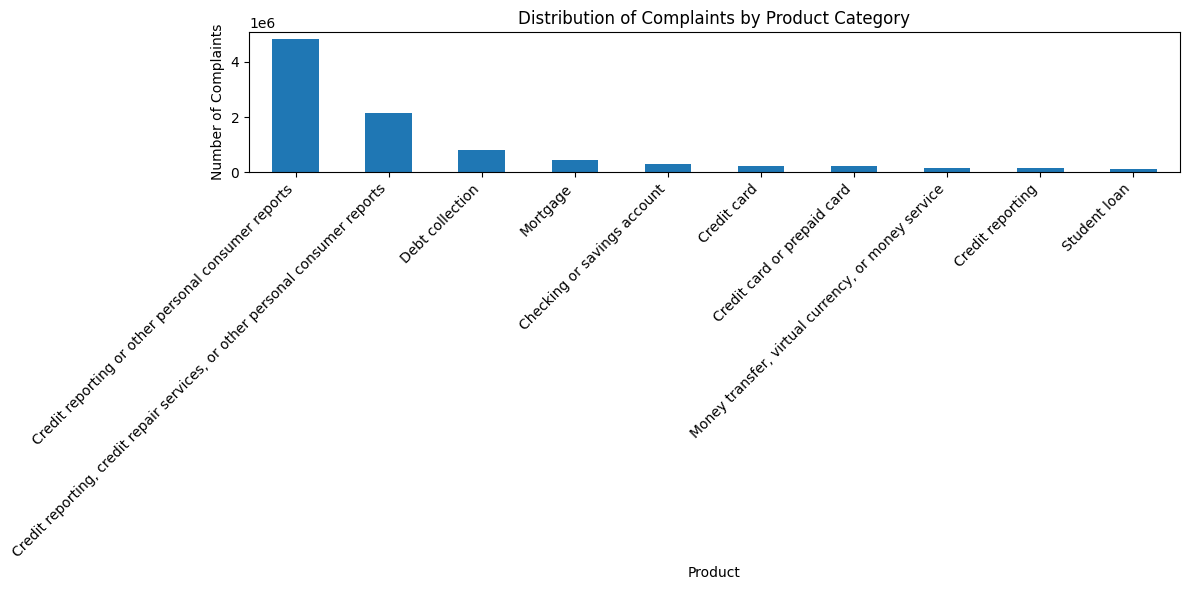

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Name: count, dtype: int64

In [4]:
# Distribution of complaints by product
product_dist = df['Product'].value_counts().head(10)

plt.figure(figsize=(12, 6))
product_dist.plot(kind='bar')
plt.title('Distribution of Complaints by Product Category')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('notebooks/product_distribution.png')
plt.show()

product_dist

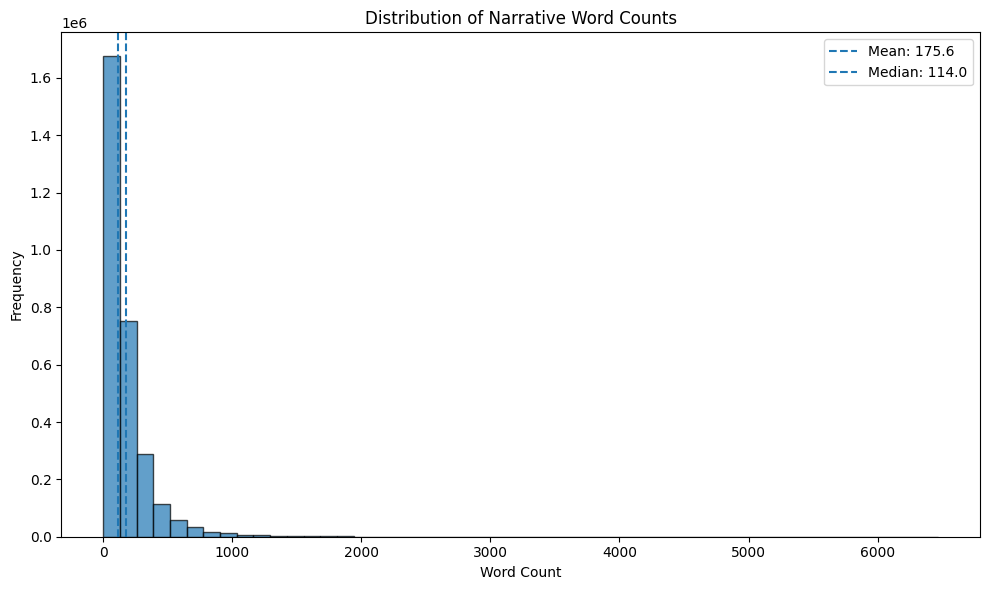

Mean: 175.6
Median: 114.0
Min/Max: 1/6469


In [5]:
# Narrative word count distribution
df['narrative_word_count'] = df['Consumer complaint narrative'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

narrative_lengths = df[df['narrative_word_count'] > 0]['narrative_word_count']

plt.figure(figsize=(10, 6))
plt.hist(narrative_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(narrative_lengths.mean(), linestyle='--', label=f"Mean: {narrative_lengths.mean():.1f}")
plt.axvline(narrative_lengths.median(), linestyle='--', label=f"Median: {narrative_lengths.median():.1f}")
plt.legend()
plt.tight_layout()
# plt.savefig('notebooks/narrative_length_distribution.png')
plt.show()

print(f"Mean: {narrative_lengths.mean():.1f}")
print(f"Median: {narrative_lengths.median():.1f}")
print(f"Min/Max: {narrative_lengths.min()}/{narrative_lengths.max()}")

## Step 3: Filter Target Products

In [6]:
target_products = [
    'Credit card',
    'Consumer Loan',
    'Bank account or service',
    'Money transfer, virtual currency'
]

df_filtered = df[df['Product'].isin(target_products)].copy()
df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].notna() &
    (df_filtered['Consumer complaint narrative'].str.len() > 0)
]

print(f"Filtered dataset shape: {df_filtered.shape[0]:,}")

Filtered dataset shape: 105,013


## Step 4: Clean Text Narratives

In [7]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', text)
    boilerplate = [
        r'i am writing to file a complaint',
        r'this is a complaint',
        r'please help',
        r'cfpb complaint'
    ]
    for phrase in boilerplate:
        text = re.sub(phrase, '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_text)

## Step 5: Save Processed Data

In [8]:
output_path = '../data/processed/filtered_complaints.csv'
df_filtered.to_csv(output_path, index=False)

df_filtered[['Complaint ID', 'Product', 'cleaned_narrative']].head(10).to_csv('../data/processed/sample_cleaned.csv', index=False)

print('Saved cleaned datasets successfully')

Saved cleaned datasets successfully
